# Adult Census Income — Préparation des données, segmentation et classification
**Lab Data Preparation 


## Sommaire
1. Business Understanding ·
2. Data Understanding · 
3. Data Exploration · 
4. Data Preparation · 
5. Segmentation · 
6. Classification ·
7. Évaluation et interprétation ·
8. Fichiers finaux

# 1. Business Understanding
## 1.1 Contexte
*Adult Census Income* (UCI) provient du recensement américain de 1994 : âge, éducation, profession, situation familiale, heures de travail, gains en capital… et une cible indiquant si le revenu annuel dépasse 50 000 $.

## 1.2 Objectifs métier et problématiques
- **Segmentation** : quels profils socio-professionnels homogènes (âge, niveau d'études, heures de travail) existent, et sont-ils stables ?
- **Classification** : peut-on prédire `income` (<=50K / >50K) de façon fiable, en particulier pour la classe minoritaire >50K ?

## 1.3 Critères de succès
- Segmentation : groupes interprétables **et stables** (ARI élevé sous ré-échantillonnage), silhouette comparée pour plusieurs k.
- Classification : cible déséquilibrée (~76 / 24) ⇒ l'accuracy seule est trompeuse. Critère principal : **F1 de la classe >50K**, complété par rappel, précision, PR-AUC et ROC-AUC.
- Livrable : fichier de données nettoyées et préparées (chapitre 8).

# 2. Data Understanding
## 2.1 Imports et chargement

In [1]:
from IPython.display import display
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
RANDOM_STATE = 42
os.makedirs("output", exist_ok=True)

In [2]:
cols = ["age","workclass","fnlwgt","education","education-num","marital-status","occupation",
        "relationship","race","sex","capital-gain","capital-loss","hours-per-week","native-country","income"]

def find(*names):
    for n in names:
        for p in (n, f"adult/{n}", f"../{n}", f"data/{n}"):
            if os.path.exists(p):
                return p
    raise FileNotFoundError(names)

path_train = find("adult.data", "adult-2.data")
path_test  = find("adult.test", "adult-3.test")

# na_values="?" : les manquants deviennent de vrais NaN, visibles par isna()
train = pd.read_csv(path_train, names=cols, skipinitialspace=True, na_values="?")
test  = pd.read_csv(path_test,  names=cols, skipinitialspace=True, na_values="?", skiprows=1)  # 1re ligne = commentaire
df = pd.concat([train, test], ignore_index=True)
print("train :", train.shape, "| test :", test.shape, "| total :", df.shape)
df.head()

train : (32561, 15) | test : (16281, 15) | total : (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Interprétation :** Les deux fichiers sont fusionnés (32 561 + 16 281 = 48 842 lignes, 15 colonnes). Grâce à `na_values="?"`, les valeurs manquantes sont de vrais `NaN` dès le chargement : elles sont visibles par `isna()` et ne passent plus inaperçues (problème de la version précédente).

## 2.2 Caractéristiques principales

In [3]:
df.info()
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print("\nNumériques    :", num_cols)
print("Catégorielles :", cat_cols)
print("Doublons exacts :", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Numériques    : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-pe

In [4]:
display(df.describe().T.round(2))
display(df.describe(exclude="number").T)

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.64,13.71,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.13,105604.03,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.07,7452.02,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.50,403.00,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.42,12.39,1.0,40.0,40.0,45.0,99.0


,count,unique,top,freq
workclass,46043,8,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,46033,14,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native-country,47985,41,United-States,43832
income,48842,4,<=50K,24720


**Interprétation :** 6 variables numériques et 9 catégorielles (dont la cible). Manquants : workclass (46 043 valeurs renseignées), occupation (46 033), native-country (47 985). Les 29 doublons exacts sont repérés *avant* de retirer `fnlwgt`, ce qui évite de supprimer de faux doublons. `capital-gain` a un maximum de 99 999 (valeur plafonnée) alors que sa médiane est 0.

# 3. Data Exploration
## 3.1 Distributions
### 3.1.1 Cible

income
<=50K    37155
>50K     11687
Name: count, dtype: int64
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


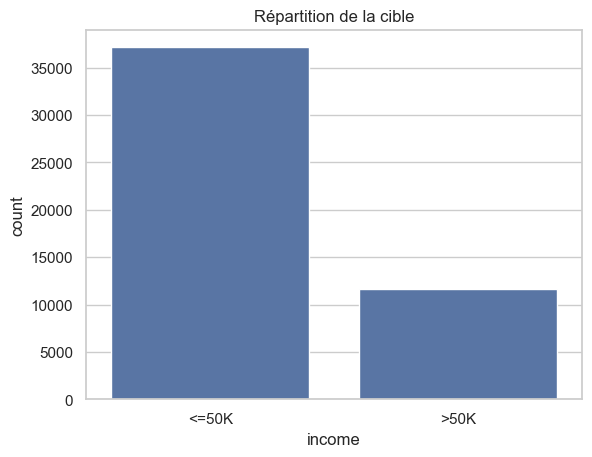

In [5]:
df["income"] = df["income"].str.strip().str.rstrip(".")      # '<=50K.' -> '<=50K'
print(df["income"].value_counts())
print((df["income"].value_counts(normalize=True) * 100).round(2))
sns.countplot(x="income", data=df, order=["<=50K", ">50K"])
plt.title("Répartition de la cible"); plt.show()

**Interprétation :** Après suppression du point final (`<=50K.` → `<=50K`), la cible a 2 modalités : 76,07 % de <=50K contre 23,93 % de >50K. Un modèle qui prédit toujours <=50K aurait 76 % d'accuracy : on utilise F1, rappel, PR-AUC et le réglage du seuil plutôt que l'accuracy seule.

### 3.1.2 Variables numériques

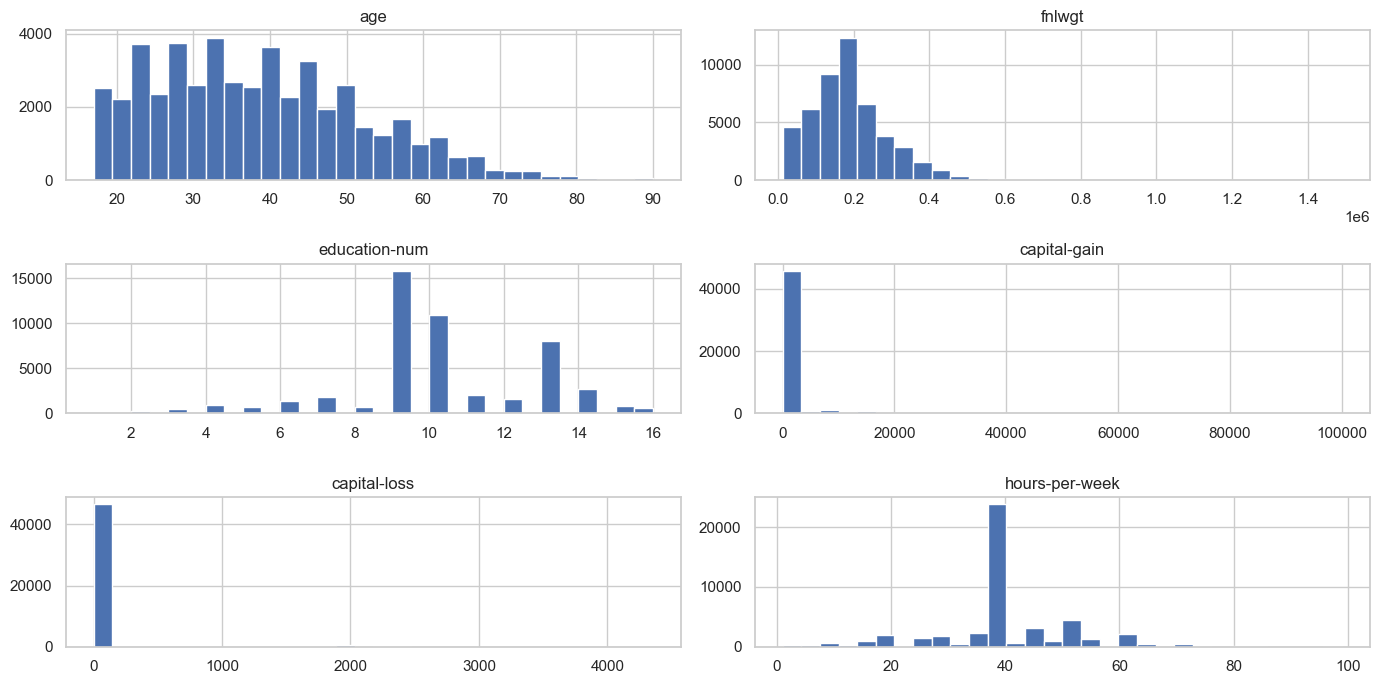

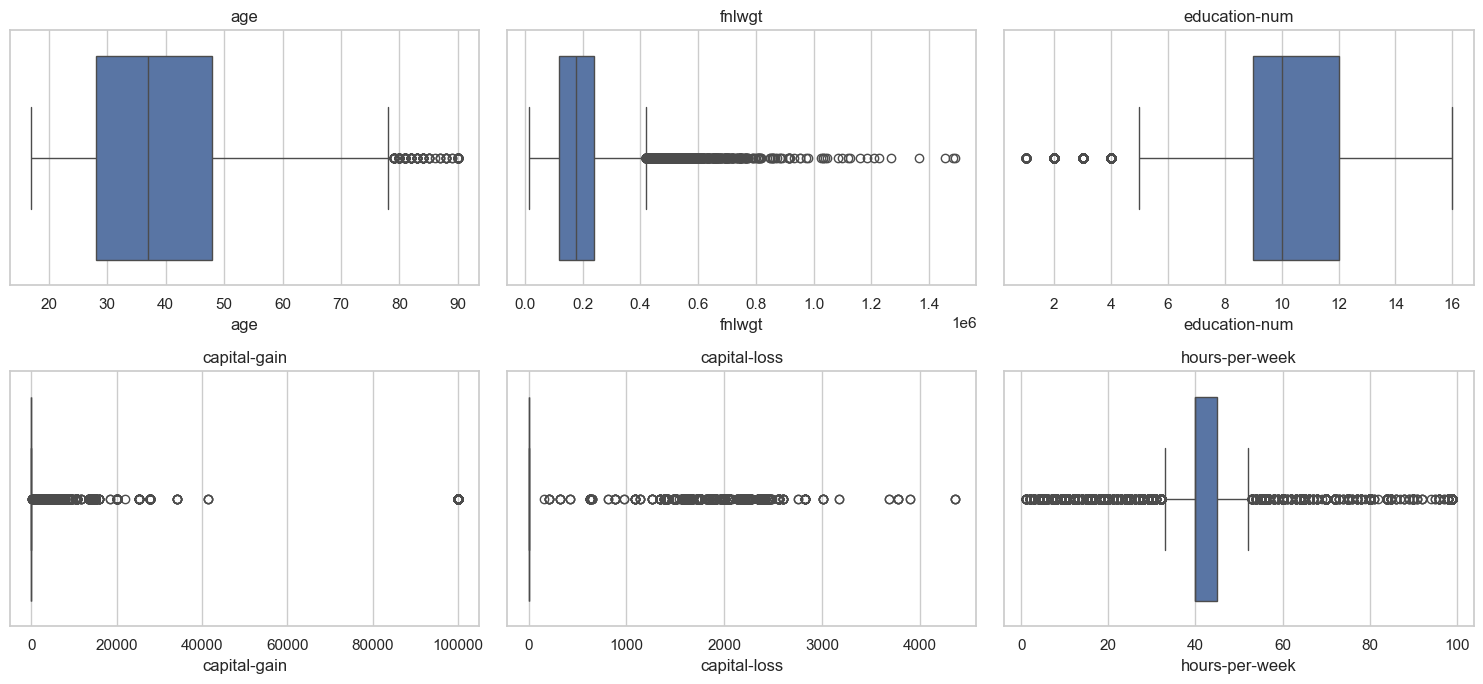

,skew,% zéros
age,0.56,NaN
fnlwgt,1.44,NaN
education-num,-0.32,NaN
capital-gain,11.89,91.7
capital-loss,4.57,95.3
hours-per-week,0.24,NaN


In [6]:
df[num_cols].hist(figsize=(14, 7), bins=30); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df[c], ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()
sk = df[num_cols].skew().round(2).rename("skew")
zeros = pd.Series({c: round((df[c]==0).mean()*100,1) for c in ["capital-gain","capital-loss"]}, name="% zéros")
display(pd.concat([sk, zeros], axis=1))

**Interprétation :** `capital-gain` (skew 11,89 ; 91,7 % de zéros) et `capital-loss` (skew 4,57 ; 95,3 % de zéros) sont extrêmement asymétriques ⇒ `log1p`. `age` (0,56), `hours-per-week` (0,24) et `education-num` (−0,32) sont proches de la symétrie. `hours-per-week` concentre un pic à 40 h, d'où de nombreux « outliers » IQR qui restent plausibles. `fnlwgt` (skew 1,44) est un poids d'échantillonnage.

### 3.1.3 Variables catégorielles

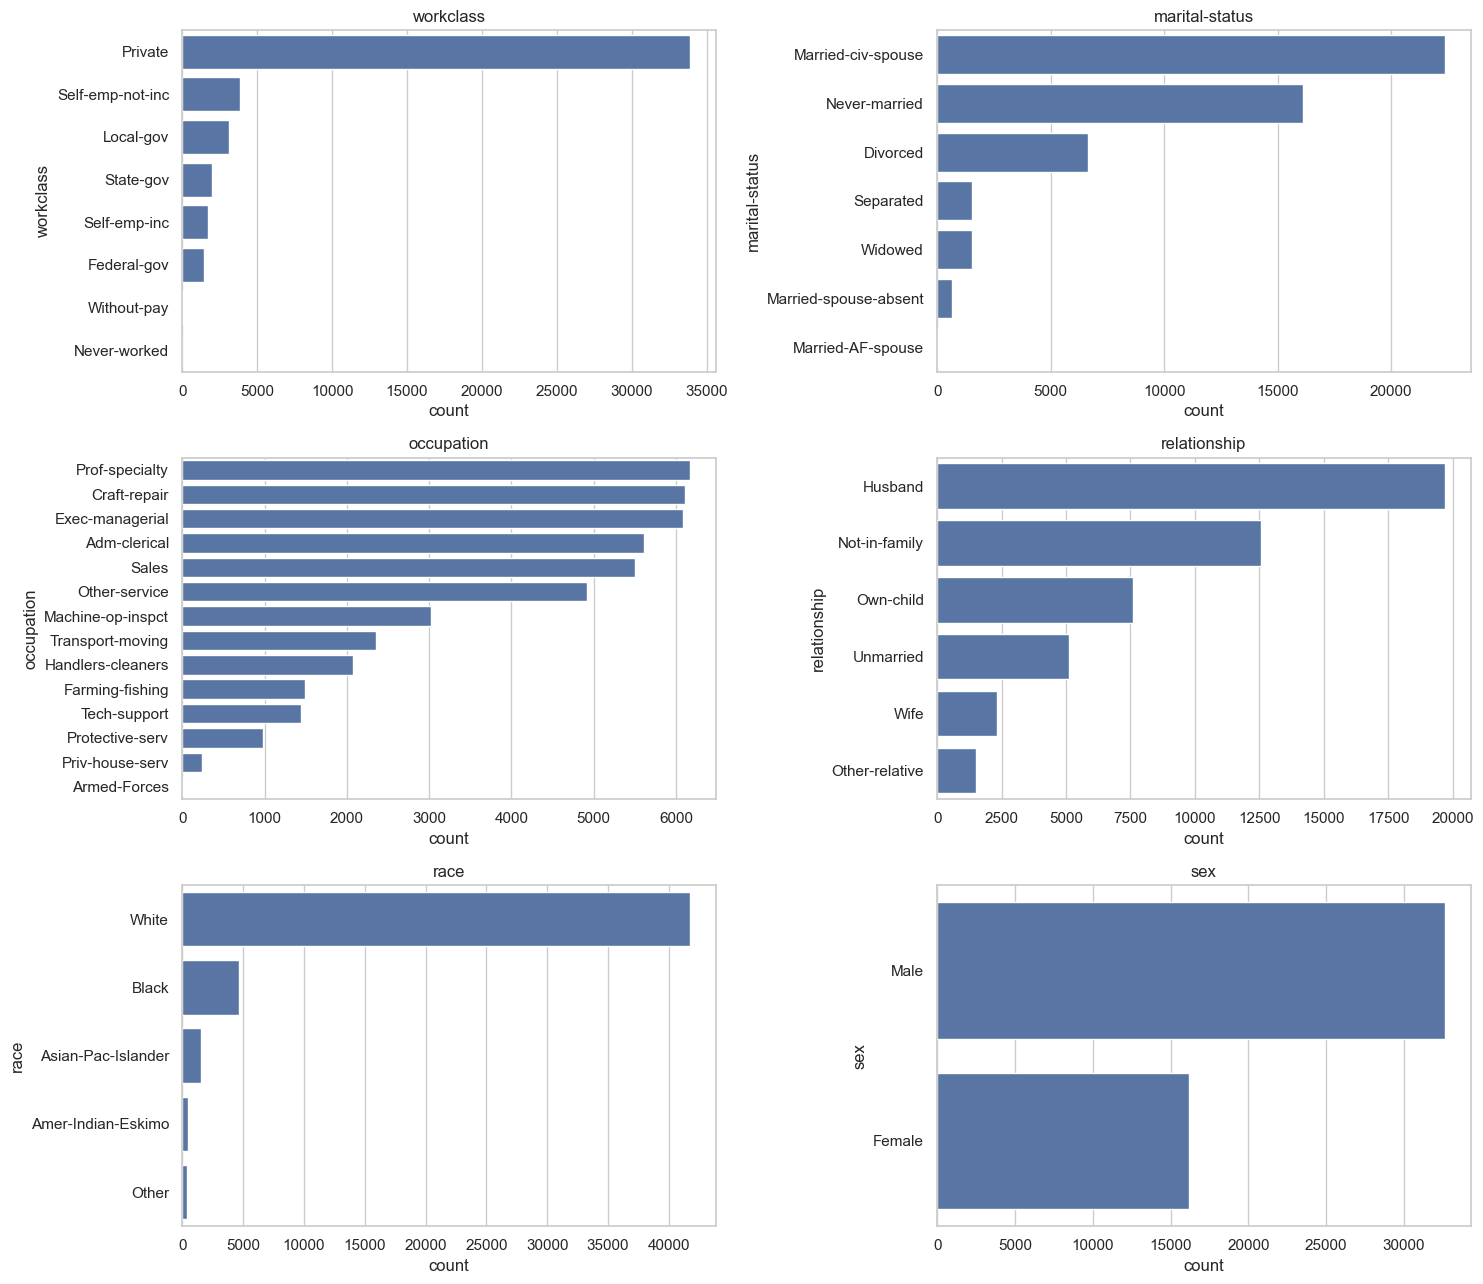

native-country
United-States    91.35
Mexico            1.98
Philippines       0.61
Germany           0.43
Puerto-Rico       0.38
Name: proportion, dtype: float64


In [7]:
cat_plot = [c for c in cat_cols if c not in ["income", "native-country", "education"]]
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
for ax, c in zip(axes.ravel(), cat_plot):
    sns.countplot(data=df, y=c, order=df[c].value_counts().index, ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()
print((df["native-country"].value_counts(normalize=True).head(5)*100).round(2))

**Interprétation :** Les catégories sont déséquilibrées : Private = 73,6 % des workclass renseignées, Married-civ-spouse = 45,8 %, White = 85,5 %, hommes = 66,8 %. `native-country` est dominé par United-States (91,35 %) ⇒ regroupement US / Autre plutôt que 40 colonnes one-hot quasi vides ; les modalités rares sont aussi regroupées via `min_frequency`.

## 3.2 Relations entre variables
### 3.2.1 Corrélations et lien avec la cible

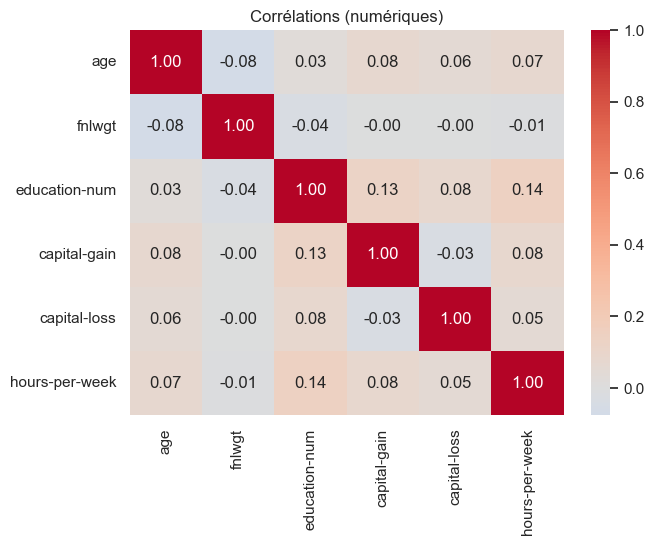

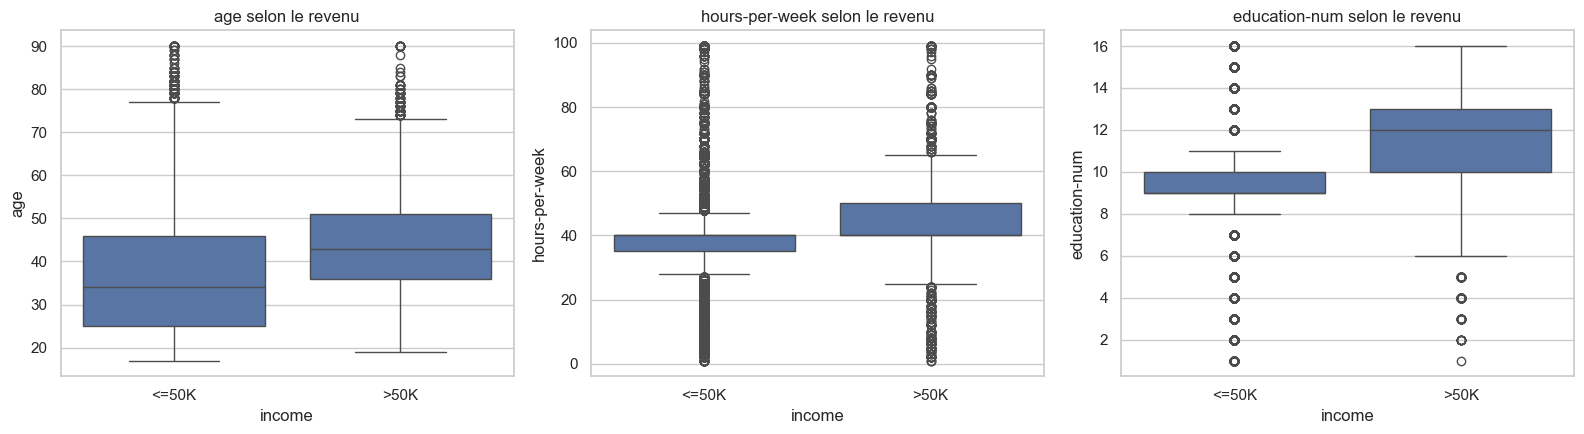

,age,hours-per-week,education-num
income,,,
<=50K,36.87,38.84,9.6
>50K,44.28,45.45,11.6


In [8]:
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations (numériques)"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, ["age", "hours-per-week", "education-num"]):
    sns.boxplot(data=df, x="income", y=c, order=["<=50K", ">50K"], ax=ax); ax.set_title(f"{c} selon le revenu")
plt.tight_layout(); plt.show()
display(df.groupby("income")[["age","hours-per-week","education-num"]].mean().round(2))

**Interprétation :** Aucune corrélation notable entre numériques (maximum 0,14 entre `education-num` et `hours-per-week`) : pas de multicolinéarité à traiter. Les personnes >50K sont plus âgées (44,3 contre 36,9 ans), travaillent plus (45,5 h contre 38,8 h) et sont plus diplômées (11,6 contre 9,6) : ces trois variables sont discriminantes.

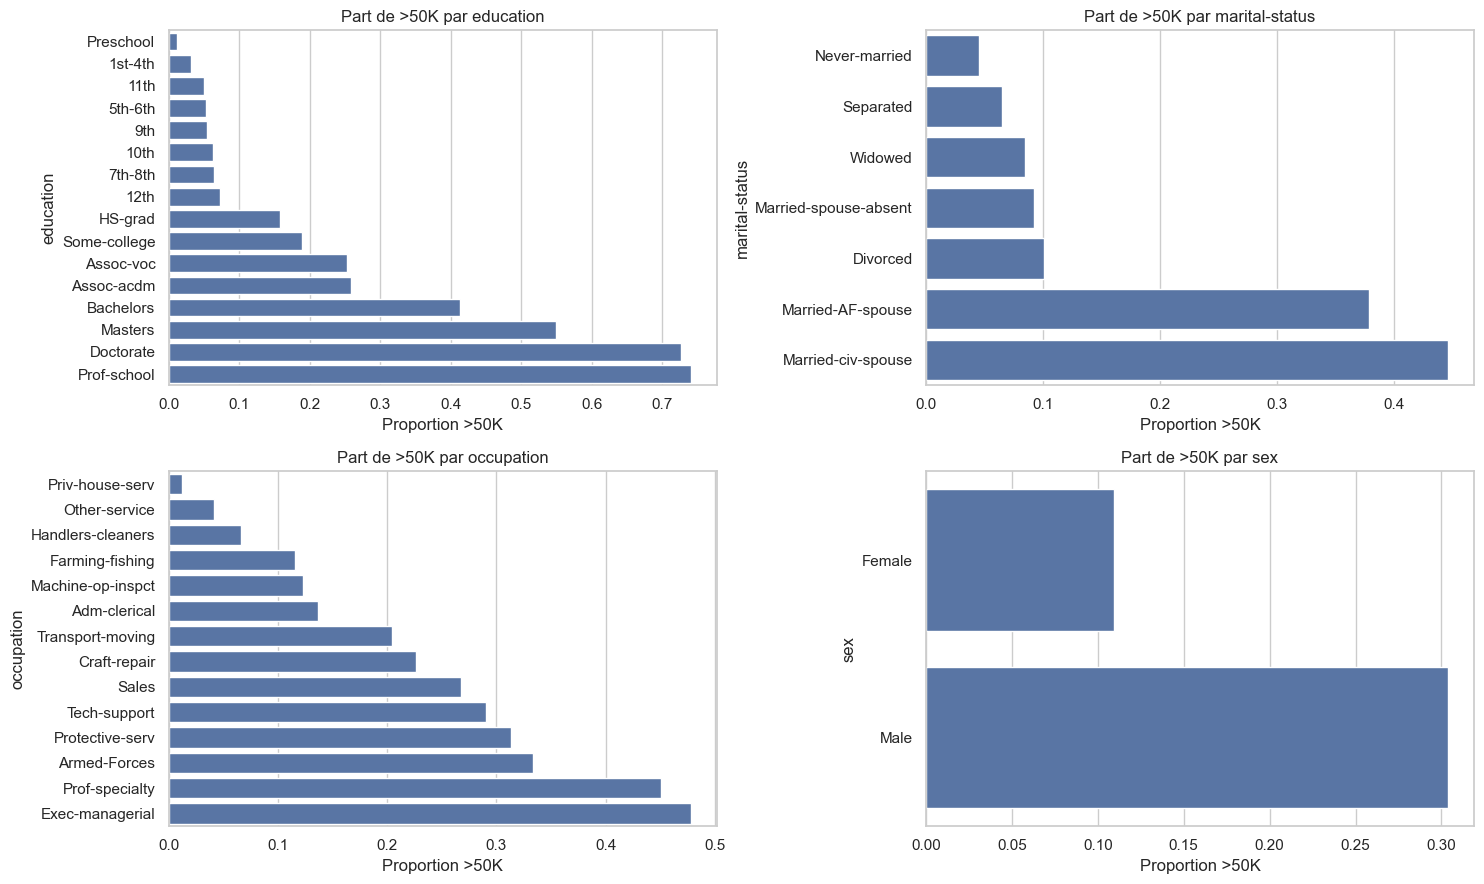

In [9]:
d = df.assign(high=(df["income"] == ">50K").astype(int))
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, c in zip(axes.ravel(), ["education", "marital-status", "occupation", "sex"]):
    r = d.groupby(c)["high"].mean().sort_values()
    sns.barplot(x=r.values, y=r.index, ax=ax); ax.set_title(f"Part de >50K par {c}"); ax.set_xlabel("Proportion >50K")
plt.tight_layout(); plt.show()

**Interprétation :** Le taux de >50K varie fortement : 30,4 % des hommes contre 10,9 % des femmes ; 44,6 % chez les mariés (Married-civ-spouse) contre 4,5 % chez les jamais mariés ; 74,0 % pour Prof-school et 72,6 % pour Doctorate contre 1,2 % pour Preschool ; Exec-managerial 47,8 %. Sexe et statut marital étant liés, le modèle peut reproduire des biais sociaux : à discuter dans l'évaluation.

## 3.3 Détection des anomalies
### 3.3.1 Valeurs manquantes

In [10]:
miss = df.isna().sum()
miss = miss[miss > 0].to_frame("manquants"); miss["%"] = (miss["manquants"]/len(df)*100).round(2)
display(miss)
print("Lignes avec au moins un manquant :", df.isna().any(axis=1).sum())
print("workclass ET occupation manquants ensemble :", (df["workclass"].isna() & df["occupation"].isna()).sum())
display(d.assign(manquant=df.isna().any(axis=1)).groupby("manquant")["high"].mean().round(3).rename("part >50K"))

,manquants,%
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


Lignes avec au moins un manquant : 3620
workclass ET occupation manquants ensemble : 2799


manquant
False    0.248
True     0.132
Name: part >50K, dtype: float64

**Interprétation :** 2 799 manquants dans workclass (5,73 %), 2 809 dans occupation (5,75 %), 857 dans native-country (1,75 %), soit 3 620 lignes. Les manquants de workclass sont **tous** aussi manquants en occupation : ils ne sont pas aléatoires. Les lignes concernées gagnent moins souvent >50K (13,2 % contre 24,8 %) : l'absence est informative ⇒ on garde la modalité `Unknown` plutôt que supprimer ou imputer par le mode.

### 3.3.2 Outliers et valeurs suspectes

In [11]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return int(((s < q1 - 1.5*i) | (s > q3 + 1.5*i)).sum())
out = pd.DataFrame({"outliers IQR": {c: iqr_outliers(df[c]) for c in num_cols}})
out["% lignes"] = (out["outliers IQR"]/len(df)*100).round(2)
display(out)
print("capital-gain = 99999 :", (df["capital-gain"]==99999).sum())
print("hours-per-week > 80  :", (df["hours-per-week"]>80).sum(), "| < 10 :", (df["hours-per-week"]<10).sum())
print("age > 85             :", (df["age"]>85).sum())
print("education <-> education-num redondants :", df.groupby("education")["education-num"].nunique().max()==1)

,outliers IQR,% lignes
age,216,0.44
fnlwgt,1453,2.97
education-num,1794,3.67
capital-gain,4035,8.26
capital-loss,2282,4.67
hours-per-week,13496,27.63


capital-gain = 99999 : 244
hours-per-week > 80  : 318 | < 10 : 700
age > 85             : 67
education <-> education-num redondants : True


**Interprétation :** `hours-per-week` compte 27,6 % d'outliers IQR uniquement à cause du pic à 40 h ; les cas extrêmes (318 personnes > 80 h, 700 < 10 h, 67 de plus de 85 ans) sont rares mais plausibles ⇒ **winsorisation** et non suppression. 244 personnes ont `capital-gain` = 99 999 (code plafonné) : conservées et traitées par `log1p`. `education` et `education-num` sont parfaitement redondantes.

## 3.4 Synthèse des anomalies et décisions
| Anomalie | Variables | Décision (et justification) |
|---|---|---|
| Manquants (`?`) | workclass, occupation, native-country | Catégorie `Unknown` : variables catégorielles, manquants non aléatoires (liés entre eux) |
| Cible avec point final | income | Harmonisée puis encodée 0/1 |
| Valeur plafonnée 99999 + forte asymétrie | capital-gain, capital-loss | `log1p` (conserve les lignes, réduit l'asymétrie) |
| Valeurs extrêmes plausibles | hours-per-week, age | **Winsorisation 1 %–99 % dans le pipeline** (bornes apprises sur le train) |
| Redondance | education / education-num | Suppression de `education` |
| Poids d'échantillonnage | fnlwgt | Suppression (non informatif pour un individu, corrélé à rien) |
| Doublons | lignes exactes | Suppression (calculée **avant** de retirer `fnlwgt`) |
| Modalités rares | native-country (91 % US) | Regroupement US / Autre + `min_frequency` dans le OneHot |
| Déséquilibre | income | `class_weight`, F1 / PR-AUC, ajustement du seuil |

# 4. Data Preparation
## 4.1 Nettoyage et feature engineering sans apprentissage (sans risque de fuite)

In [12]:
def clean_raw(data):
    out = data.drop_duplicates().reset_index(drop=True)             # doublons exacts (fnlwgt encore présent)
    out["income"] = out["income"].map({"<=50K": 0, ">50K": 1}).astype(int)
    out["native_us"] = (out["native-country"] == "United-States").astype(float).where(out["native-country"].notna())
    out["is_married"] = out["marital-status"].isin(["Married-civ-spouse", "Married-AF-spouse"]).astype(int)
    out["has_capital_gain"] = (out["capital-gain"] > 0).astype(int)
    out["has_capital_loss"] = (out["capital-loss"] > 0).astype(int)
    return out.drop(columns=["education", "fnlwgt", "native-country"])

df_clean = clean_raw(df)
print("Avant :", df.shape, "| Après :", df_clean.shape)
print("Doublons exacts supprimés :", len(df) - len(df_clean))
print("Lignes identiques sur les colonnes conservées (individus distincts, conservées) :", df_clean.duplicated().sum())
print(df_clean["income"].value_counts(normalize=True).round(4).to_dict())
df_clean.head()

Avant : (48842, 15) | Après : (48790, 16)
Doublons exacts supprimés : 52
Lignes identiques sur les colonnes conservées (individus distincts, conservées) : 6372
{0: 0.7606, 1: 0.2394}


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,income,native_us,is_married,has_capital_gain,has_capital_loss
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,0,1.0,0,1,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,0,1.0,1,0,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,0,1.0,0,0,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,0,1.0,1,0,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,0,0.0,1,0,0


**Interprétation :** 52 doublons exacts sont supprimés (29 détectés avant harmonisation de la cible ; 23 de plus apparaissent entre train et test une fois le point final de `<=50K.` retiré) : 48 790 lignes restent. Les 6 372 lignes encore « identiques » affichées sont uniquement dues au retrait de `fnlwgt` : ce sont des individus distincts, **non supprimés** (cela retirerait ~13 % de données légitimes). Nouvelles variables : `native_us`, `is_married`, `has_capital_gain`, `has_capital_loss`. Proportion de la cible inchangée : 76,06 / 23,94.

## 4.2 Séparation entraînement / test **avant** toute statistique apprise
Le découpage 80/20 stratifié est fait maintenant : bornes, médianes, moyennes et catégories seront apprises sur `X_train` uniquement.

In [13]:
X = df_clean.drop(columns="income"); y = df_clean["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)
print(pd.DataFrame({"train %": y_train.value_counts(normalize=True)*100,
                    "test %": y_test.value_counts(normalize=True)*100}).round(2))

(39032, 15) (9758, 15)
        train %  test %
income                 
0         76.06   76.06
1         23.94   23.94


**Interprétation :** Découpage 80/20 stratifié : 39 032 lignes d'entraînement et 9 758 de test, avec exactement la même proportion de >50K (23,94 %). Il est réalisé **avant** tout apprentissage de statistique, ce qui supprime la fuite de données de la version précédente (bornes calculées sur tout le dataset).

## 4.3 Pipeline de prétraitement avec bornage (winsorisation) intégré
- `Winsorizer` : apprend les percentiles 1 % / 99 % **sur le train** puis écrête (train et test). Le bornage est donc refait à l'intérieur du pipeline, et recalculé à chaque pli de validation croisée.
- `log1p` sur les gains/pertes en capital, puis standardisation.
- Catégorielles : imputation par `Unknown`, one-hot avec regroupement des modalités < 1 % ; catégories inconnues ignorées.

In [14]:
class Winsorizer(BaseEstimator, TransformerMixin):
    # Écrête chaque colonne entre deux quantiles appris pendant fit (donc uniquement sur le train).
    def __init__(self, lower=0.01, upper=0.99):
        self.lower, self.upper = lower, upper
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.low_, self.high_ = np.quantile(X, self.lower, axis=0), np.quantile(X, self.upper, axis=0)
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.low_, self.high_)
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

wins_cols    = ["age", "hours-per-week", "education-num"]
capital_cols = ["capital-gain", "capital-loss"]
binary_cols  = ["is_married", "has_capital_gain", "has_capital_loss"]
cat_cols_ml  = ["workclass", "marital-status", "occupation", "relationship", "race", "sex"]

def make_preprocessor():
    return ColumnTransformer([
        ("wins",    Pipeline([("w", Winsorizer(0.01, 0.99)), ("s", StandardScaler())]), wins_cols),
        ("capital", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                              ("s", StandardScaler())]), capital_cols),
        ("native",  SimpleImputer(strategy="most_frequent"), ["native_us"]),
        ("bin",     "passthrough", binary_cols),
        ("cat",     Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
                              ("oh", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01,
                                                   sparse_output=False))]), cat_cols_ml),
    ])

prep = make_preprocessor().fit(X_train)
Xt = prep.transform(X_train)
w = prep.named_transformers_["wins"].named_steps["w"]
print("Bornes apprises sur le train :")
display(pd.DataFrame({"borne basse": w.low_, "borne haute": w.high_}, index=wins_cols))
print("Matrice transformée :", Xt.shape, "| NaN :", int(np.isnan(Xt).sum()))
print("native-country manquants imputés par le mode (US) :", int(X_train["native_us"].isna().sum()))

Bornes apprises sur le train :


,borne basse,borne haute
age,17.0,74.0
hours-per-week,8.0,80.0
education-num,3.0,16.0


Matrice transformée : (39032, 50) | NaN : 0
native-country manquants imputés par le mode (US) : 671


**Interprétation :** Les bornes sont apprises sur le train seulement : `hours-per-week` ∈ [8 ; 80], `age` ∈ [17 ; 74], `education-num` ∈ [3 ; 16]. La matrice transformée compte 50 colonnes sans aucun NaN. 671 valeurs manquantes de `native_us` sont imputées par le mode (US), cohérent avec la dominance de cette modalité. Comme le `Winsorizer` est dans le pipeline, il est ré-ajusté à chaque pli de validation croisée : le bornage est donc refait correctement.

# 5. Segmentation (clustering)
## 5.1 Variables et préparation
Profils selon **age, education-num, hours-per-week** (interprétables, `income` exclu). Winsorisation puis standardisation : K-Means repose sur les distances, donc sensible aux échelles et aux valeurs extrêmes. Le clustering est non supervisé : il est appliqué à l'ensemble des individus nettoyés.

In [15]:
seg_vars = ["age", "education-num", "hours-per-week"]
seg_prep = Pipeline([("w", Winsorizer(0.01, 0.99)), ("s", StandardScaler())])
Xs = seg_prep.fit_transform(df_clean[seg_vars])
print(Xs.shape, "| moyennes :", Xs.mean(0).round(3), "| écarts-types :", Xs.std(0).round(3))

(48790, 3) | moyennes : [ 0. -0.  0.] | écarts-types : [1. 1. 1.]


**Interprétation :** Les 3 variables sont écrêtées puis standardisées (moyenne 0, écart-type 1) : K-Means utilise la distance euclidienne, donc sans cela les heures (étendue large) domineraient. `income` n'est pas utilisée, pour que les groupes soient purement descriptifs.

## 5.2 Choix du nombre de clusters : silhouette, Davies-Bouldin, Calinski-Harabasz et stabilité

,inertie,silhouette,Davies-Bouldin,Calinski-Harabasz,ARI stabilité (moy),ARI stabilité (écart-type)
k,,,,,,
2,110725.639,0.247,1.540,15705.654,0.897,0.139
3,84001.140,0.297,1.183,18111.612,0.986,0.006
4,70445.025,0.310,1.084,17527.143,0.850,0.204
5,59465.921,0.324,1.025,17823.729,0.953,0.105
6,51462.862,0.336,0.993,17993.385,0.940,0.097
7,44904.997,0.342,0.940,18371.286,0.977,0.058
8,39896.999,0.339,0.943,18597.778,0.988,0.005


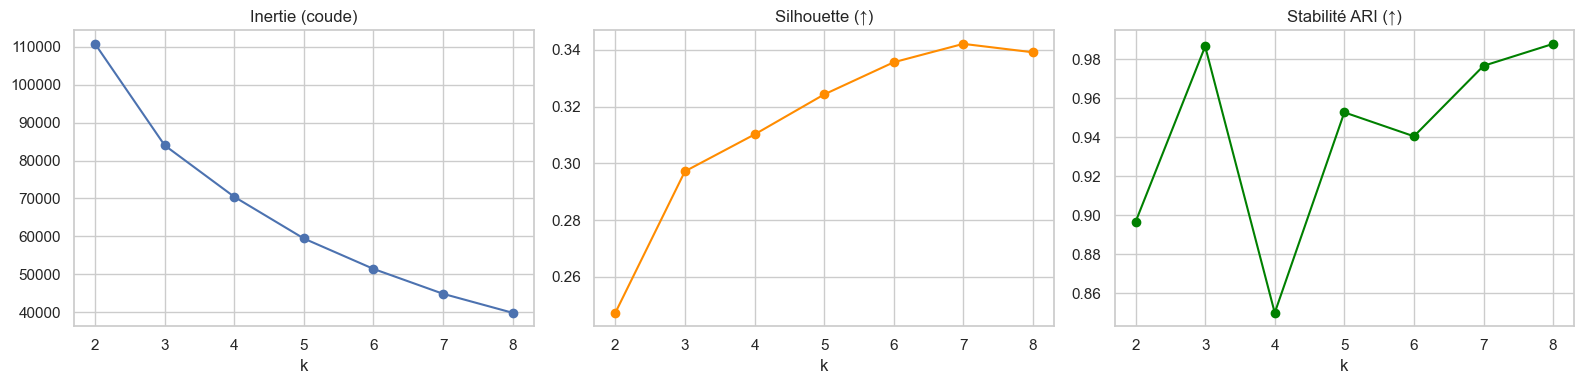

In [16]:
def stability_ari(Xs, k, n_boot=15, frac=0.8, seed=0):
    # ARI entre la partition de référence et celle obtenue en entraînant sur 80 % des données (appliquée à toutes)
    ref = KMeans(k, n_init=10, random_state=seed).fit(Xs).labels_
    rng = np.random.RandomState(seed); aris = []
    for b in range(n_boot):
        idx = rng.choice(len(Xs), int(frac*len(Xs)), replace=False)
        m = KMeans(k, n_init=3, random_state=b).fit(Xs[idx])
        aris.append(adjusted_rand_score(ref, m.predict(Xs)))
    return np.mean(aris), np.std(aris)

rows, models_km = [], {}
for k in range(2, 9):
    km = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(Xs); models_km[k] = km
    sil = silhouette_score(Xs, km.labels_, sample_size=8000, random_state=RANDOM_STATE)
    m, s = stability_ari(Xs, k)
    rows.append({"k": k, "inertie": km.inertia_, "silhouette": sil,
                 "Davies-Bouldin": davies_bouldin_score(Xs, km.labels_),
                 "Calinski-Harabasz": calinski_harabasz_score(Xs, km.labels_),
                 "ARI stabilité (moy)": m, "ARI stabilité (écart-type)": s})
scores_seg = pd.DataFrame(rows).set_index("k")
display(scores_seg.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
scores_seg["inertie"].plot(marker="o", ax=axes[0], title="Inertie (coude)")
scores_seg["silhouette"].plot(marker="o", color="darkorange", ax=axes[1], title="Silhouette (↑)")
scores_seg["ARI stabilité (moy)"].plot(marker="o", color="green", ax=axes[2], title="Stabilité ARI (↑)")
plt.tight_layout(); plt.show()

**Interprétation :** La silhouette croît de 0,247 (k=2) à 0,342 (k=7) puis stagne à 0,339 (k=8) ; Davies-Bouldin est minimal à k=7 (0,940). L'inertie n'a pas de coude net. Côté stabilité (ARI sur sous-échantillons de 80 %), k=3 (0,986) et k=8 (0,988) sont les plus stables ; k=4 (0,850, écart-type 0,204) et k=2 sont instables. k=7 combine la meilleure silhouette et une bonne stabilité (0,977) : c'est le choix de la règle « meilleure silhouette parmi les k stables (ARI ≥ 0,85) ». On ne choisit donc plus k sur la silhouette seule.

## 5.3 Stabilité complémentaire : graines multiples et algorithmes alternatifs

In [17]:
K = int(scores_seg["silhouette"].where(scores_seg["ARI stabilité (moy)"] >= 0.85).idxmax())   # meilleure silhouette parmi les k stables
print("k retenu :", K)

ref = models_km[K].labels_
seeds_ari = [adjusted_rand_score(ref, KMeans(K, n_init=1, random_state=s).fit(Xs).labels_) for s in range(10)]
print(f"ARI entre 10 initialisations aléatoires et la référence : moyenne {np.mean(seeds_ari):.3f}, min {np.min(seeds_ari):.3f}")

gmm_lab = GaussianMixture(K, random_state=RANDOM_STATE, n_init=3).fit_predict(Xs)
rng = np.random.RandomState(RANDOM_STATE); sub = rng.choice(len(Xs), 8000, replace=False)
agg_lab = AgglomerativeClustering(K, linkage="ward").fit_predict(Xs[sub])
comp = pd.DataFrame({
    "Algorithme": ["K-Means", "GMM", "Ward (échantillon 8000)"],
    "Silhouette": [silhouette_score(Xs, ref, sample_size=8000, random_state=RANDOM_STATE),
                   silhouette_score(Xs, gmm_lab, sample_size=8000, random_state=RANDOM_STATE),
                   silhouette_score(Xs[sub], agg_lab)],
    "ARI vs K-Means": [1.0, adjusted_rand_score(ref, gmm_lab), adjusted_rand_score(ref[sub], agg_lab)]})
display(comp.round(3))

k retenu : 7
ARI entre 10 initialisations aléatoires et la référence : moyenne 0.892, min 0.727


,Algorithme,Silhouette,ARI vs K-Means
0,K-Means,0.342,1.000
1,GMM,0.028,0.189
2,Ward (échantillon 8000),0.225,0.482


,Algorithme,Silhouette,ARI vs K-Means
0,K-Means,0.342,1.000
1,GMM,0.028,0.189
2,Ward (échantillon 8000),0.225,0.482


**Interprétation :** Avec 10 initialisations aléatoires à une seule exécution, l'ARI moyen avec la partition de référence est de 0,892 (minimum 0,727) : les groupes principaux sont reproductibles, mais certaines frontières bougent selon l'initialisation (d'où `n_init=10` pour la solution finale). GMM (silhouette 0,028 ; ARI 0,189) et Ward (silhouette 0,225 ; ARI 0,482) donnent des partitions différentes : les données forment un continuum sans frontières nettes, et K-Means reste la solution la plus compacte et la plus interprétable. **Limite** : la structure est modérée (silhouette ≈ 0,34).

## 5.4 Description et interprétation des profils

,Effectif,Age,Etudes,Heures,Pct_sup50K,Part_%
cluster,,,,,,
0,2008,64.16,9.89,17.31,14.24,4.12
1,4802,23.19,9.43,20.37,2.44,9.84
2,3999,40.29,10.65,65.51,38.73,8.20
3,14592,29.28,9.31,41.06,11.10,29.91
4,10632,39.31,13.37,42.96,47.35,21.79
5,9575,51.63,9.58,41.22,29.78,19.62
6,3182,45.59,4.49,40.01,7.04,6.52


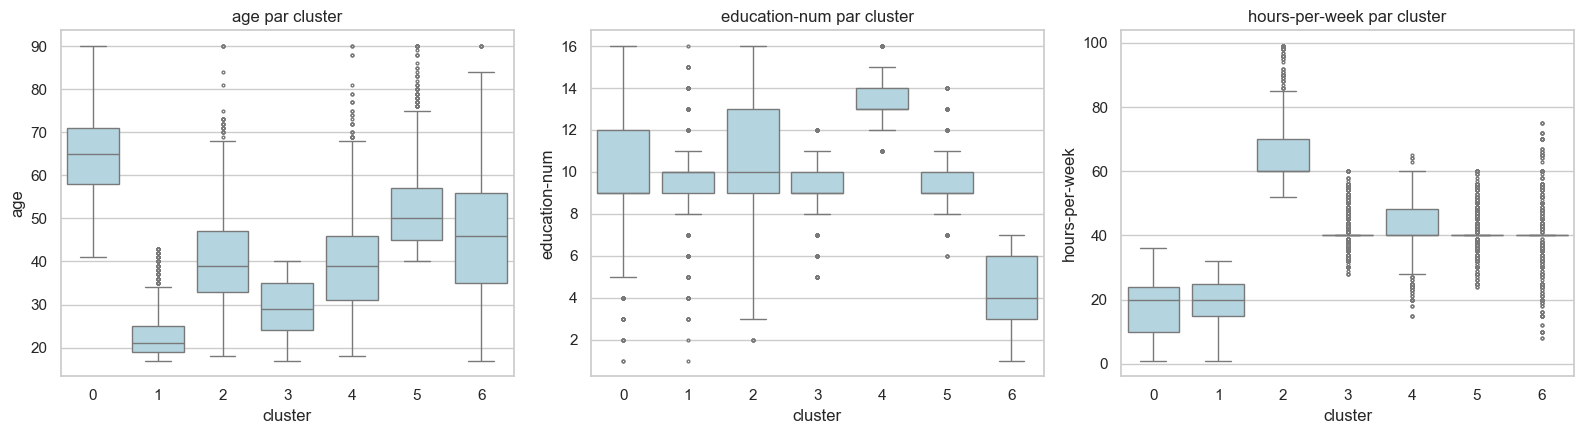

,age,education-num,hours-per-week
cluster,,,
0,63.5,9.9,17.8
1,23.2,9.4,20.5
2,40.3,10.6,64.5
3,29.3,9.3,41.0
4,39.3,13.4,43.0
5,51.5,9.6,41.2
6,45.5,4.6,40.0


In [18]:
data_seg = df_clean.copy(); data_seg["cluster"] = ref
prof = data_seg.groupby("cluster").agg(Effectif=("age","size"), Age=("age","mean"),
        Etudes=("education-num","mean"), Heures=("hours-per-week","mean"),
        Pct_sup50K=("income", lambda s: 100*s.mean()))
prof["Part_%"] = prof["Effectif"]/len(data_seg)*100
display(prof.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, v in zip(axes, seg_vars):
    sns.boxplot(data=data_seg, x="cluster", y=v, color="lightblue", fliersize=2, ax=ax); ax.set_title(f"{v} par cluster")
plt.tight_layout(); plt.show()

centres = pd.DataFrame(seg_prep.named_steps["s"].inverse_transform(models_km[K].cluster_centers_), columns=seg_vars)
centres.index.name = "cluster"; display(centres.round(1))

**Interprétation :** 7 profils : **0** retraités (64 ans, 17 h/sem., 4 %) ; **1** jeunes à temps partiel / étudiants (23 ans, 20 h, 9,8 %, 2,4 % >50K) ; **2** surtravailleurs (65 h/sem., 38,7 % >50K) ; **3** jeunes actifs (29 ans, 41 h, 29,9 %, 11,1 % >50K) ; **4** très diplômés (13,4 années d'études, 21,8 %, 47,4 % >50K) ; **5** seniors actifs (52 ans, 41 h, 29,8 % >50K) ; **6** faible niveau d'études (4,5 ; 7,0 % >50K). Le revenu n'a pas servi à construire les groupes, pourtant il les différencie nettement (2,4 % à 47,4 %) : association, pas causalité.

# 6. Classification
## 6.1 Comparaison de plusieurs modèles (validation croisée 5 plis sur le train)
Chaque modèle est encapsulé dans un `Pipeline` complet (prétraitement + bornage + modèle) : tout est réappris dans chaque pli. Le déséquilibre est géré par `class_weight="balanced"`.

In [19]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
models = {
    "Référence majoritaire": DummyClassifier(strategy="most_frequent"),
    "Régression logistique": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "Arbre de décision":     DecisionTreeClassifier(max_depth=8, min_samples_leaf=30, class_weight="balanced", random_state=RANDOM_STATE),
    "Forêt aléatoire":       RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient boosting":     HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
}
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1",
           "roc_auc": "roc_auc", "pr_auc": "average_precision"}
rows = []
for name, mdl in models.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", mdl)])
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({"Modèle": name, **{m: r[f"test_{m}"].mean() for m in scoring}, "F1 écart-type": r["test_f1"].std()})
cv_table = pd.DataFrame(rows).set_index("Modèle")
display(cv_table.round(4))

,accuracy,precision,recall,f1,roc_auc,pr_auc,F1 écart-type
Modèle,,,,,,,
Référence majoritaire,0.7606,0.0000,0.0000,0.0000,0.5000,0.2394,0.0000
Régression logistique,0.8086,0.5670,0.8493,0.6800,0.9060,0.7622,0.0080
Arbre de décision,0.8019,0.5561,0.8556,0.6740,0.9036,0.7463,0.0041
Forêt aléatoire,0.8284,0.6009,0.8431,0.7017,0.9183,0.8027,0.0069
Gradient boosting,0.8331,0.6056,0.8688,0.7137,0.9280,0.8264,0.0059


**Interprétation :** Avec `class_weight="balanced"`, les modèles favorisent le rappel (≈ 0,84–0,87) au détriment de la précision (≈ 0,56–0,61), d'où des accuracies de 0,80–0,83. La référence majoritaire a 0,76 d'accuracy mais un F1 nul. Le **gradient boosting** est le meilleur : F1 = 0,714, ROC-AUC = 0,928, PR-AUC = 0,826, devant la forêt aléatoire (F1 0,702), la régression logistique (0,680) et l'arbre (0,674). Les écarts-types des plis sont faibles (≤ 0,008) : le classement est fiable.

## 6.2 Réglage des hyperparamètres (GridSearchCV, critère PR-AUC indépendant du seuil)

In [20]:
grids = {
    "Régression logistique": {"model__C": [0.1, 1, 10]},
    "Forêt aléatoire":       {"model__max_depth": [12, 20, None], "model__min_samples_leaf": [3, 8]},
    "Gradient boosting":     {"model__learning_rate": [0.05, 0.1], "model__max_leaf_nodes": [15, 31], "model__l2_regularization": [0.0, 1.0]},
}
tuned, tune_rows = {}, []
for name, grid in grids.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", clone(models[name]))])
    gs = GridSearchCV(pipe, grid, scoring="average_precision", cv=cv, n_jobs=1, refit=True).fit(X_train, y_train)
    tuned[name] = gs.best_estimator_
    tune_rows.append({"Modèle": name, "Meilleurs paramètres": str({k.replace("model__",""): v for k, v in gs.best_params_.items()}),
                      "PR-AUC CV": gs.best_score_})
display(pd.DataFrame(tune_rows).set_index("Modèle").round(4))

,Meilleurs paramètres,PR-AUC CV
Modèle,,
Régression logistique,{'C': 10},0.7707
Forêt aléatoire,"{'max_depth': 20, 'min_samples_leaf': 3}",0.8044
Gradient boosting,"{'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_leaf_nodes': 31}",0.8264


**Interprétation :** Le réglage n'améliore pas le gradient boosting (PR-AUC 0,826, comme par défaut) mais confirme son avantage sur la forêt (0,804) et la régression logistique (0,771, C = 10). Le modèle est peu sensible aux hyperparamètres testés, signe de robustesse. Les paramètres retenus figurent dans le tableau.

## 6.3 Ajustement du seuil de décision
Le seuil par défaut (0,5) n'est pas optimal pour une classe minoritaire. Le seuil est choisi pour **maximiser le F1 de >50K** à partir des probabilités *out-of-fold* du train : le test n'est jamais utilisé pour cela.

,"F1 à 0,5",Seuil optimal,F1 au seuil optimal,Recall au seuil optimal,Precision au seuil optimal
Modèle,,,,,
Régression logistique,0.6827,0.5928,0.6912,0.7760,0.6231
Forêt aléatoire,0.7023,0.6010,0.7150,0.7640,0.6719
Gradient boosting,0.7137,0.6025,0.7262,0.8089,0.6589


Modèle retenu : Gradient boosting | seuil : 0.602


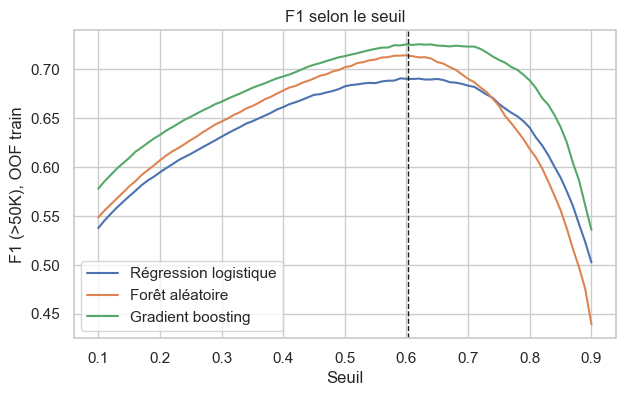

In [21]:
def best_threshold(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2*p[:-1]*r[:-1]/np.clip(p[:-1]+r[:-1], 1e-12, None)
    return t[np.argmax(f1)], f1.max()

oof, rows = {}, []
for name, pipe in tuned.items():
    oof[name] = cross_val_predict(clone(pipe), X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]
    thr, f1_opt = best_threshold(y_train, oof[name])
    rows.append({"Modèle": name, "F1 à 0,5": f1_score(y_train, oof[name] >= 0.5), "Seuil optimal": thr,
                 "F1 au seuil optimal": f1_opt,
                 "Recall au seuil optimal": recall_score(y_train, oof[name] >= thr),
                 "Precision au seuil optimal": precision_score(y_train, oof[name] >= thr)})
thr_table = pd.DataFrame(rows).set_index("Modèle")
display(thr_table.round(4))

name_best = thr_table["F1 au seuil optimal"].idxmax()
THR = float(thr_table.loc[name_best, "Seuil optimal"])
print("Modèle retenu :", name_best, "| seuil :", round(THR, 3))

ts = np.linspace(0.1, 0.9, 81)
plt.figure(figsize=(7,4))
for name in oof:
    plt.plot(ts, [f1_score(y_train, oof[name] >= t) for t in ts], label=name)
plt.axvline(THR, color="k", ls="--", lw=1); plt.xlabel("Seuil"); plt.ylabel("F1 (>50K), OOF train"); plt.legend(); plt.title("F1 selon le seuil"); plt.show()

**Interprétation :** Le seuil optimal (probabilités out-of-fold) est d'environ 0,60 pour les trois modèles et non 0,5 : `class_weight="balanced"` surestime la classe >50K, il faut donc relever le seuil. Pour le gradient boosting, le F1 passe de 0,714 à 0,726, la précision monte à 0,659 et le rappel reste à 0,809. Le gain est modeste mais systématique. Modèle retenu : gradient boosting, seuil ≈ 0,60.

# 7. Évaluation et interprétation des résultats
## 7.1 Évaluation finale sur le test (utilisé une seule fois)

In [22]:
final = clone(tuned[name_best]).fit(X_train, y_train)
proba = final.predict_proba(X_test)[:, 1]

def metrics(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    return {"Accuracy": accuracy_score(y_true, pred), "Balanced acc.": balanced_accuracy_score(y_true, pred),
            "Precision >50K": precision_score(y_true, pred), "Recall >50K": recall_score(y_true, pred),
            "F1 >50K": f1_score(y_true, pred), "ROC-AUC": roc_auc_score(y_true, proba),
            "PR-AUC": average_precision_score(y_true, proba)}

res = pd.DataFrame({"Seuil 0,5": metrics(y_test, proba, 0.5), f"Seuil ajusté ({THR:.2f})": metrics(y_test, proba, THR)}).T
display(res.round(4))
print(classification_report(y_test, (proba >= THR).astype(int), target_names=["<=50K", ">50K"], digits=3))

,Accuracy,Balanced acc.,Precision >50K,Recall >50K,F1 >50K,ROC-AUC,PR-AUC
"Seuil 0,5",0.8319,0.8465,0.6027,0.8746,0.7136,0.9329,0.8408
Seuil ajusté (0.60),0.8514,0.8388,0.6517,0.8146,0.7241,0.9329,0.8408


              precision    recall  f1-score   support

       <=50K      0.937     0.863     0.898      7422
        >50K      0.652     0.815     0.724      2336

    accuracy                          0.851      9758
   macro avg      0.794     0.839     0.811      9758
weighted avg      0.868     0.851     0.857      9758



**Interprétation :** Sur le test (9 758 lignes, utilisé une seule fois) : F1 >50K = 0,724 avec le seuil ajusté (0,714 à 0,5), précision 0,652, rappel 0,815, accuracy 0,851, ROC-AUC 0,933, PR-AUC 0,841. C'est cohérent avec la validation croisée (F1 0,726) : pas de sur-apprentissage visible. Par rapport à la version précédente (régression logistique : F1 0,672, rappel 0,614), le rappel de >50K passe de 61 % à 81 %.

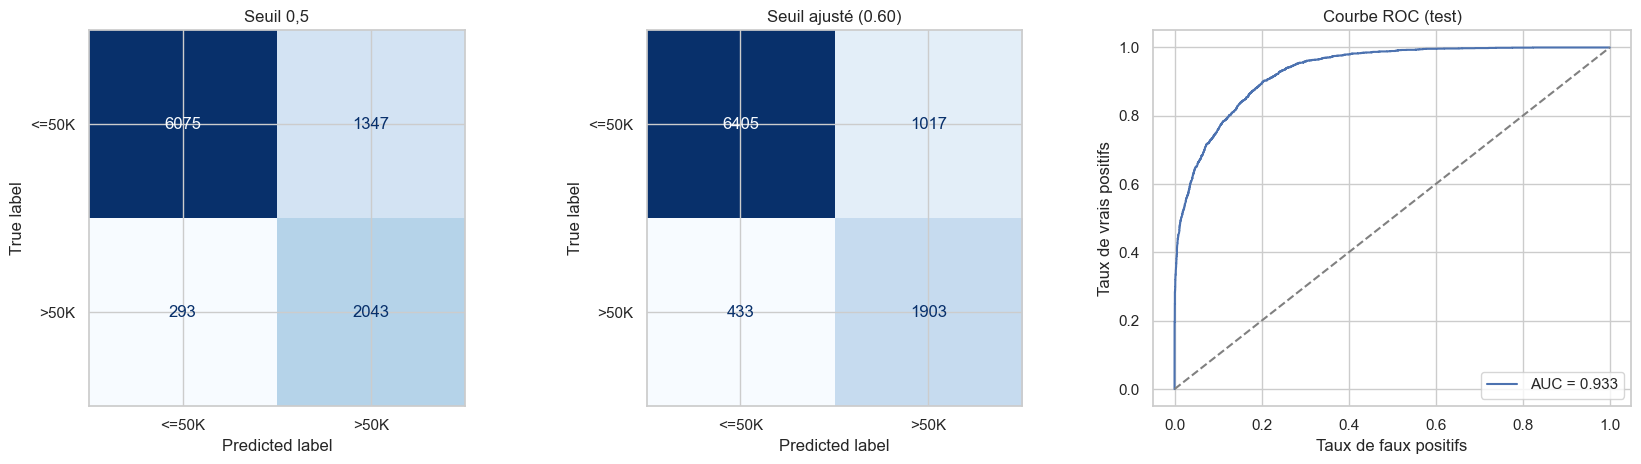

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, thr, title in zip(axes[:2], [0.5, THR], ["Seuil 0,5", f"Seuil ajusté ({THR:.2f})"]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, proba >= thr), display_labels=["<=50K", ">50K"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
fpr, tpr, _ = roc_curve(y_test, proba)
axes[2].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}"); axes[2].plot([0,1],[0,1],"--",color="gray")
axes[2].set_xlabel("Taux de faux positifs"); axes[2].set_ylabel("Taux de vrais positifs"); axes[2].set_title("Courbe ROC (test)"); axes[2].legend()
plt.tight_layout(); plt.show()

**Interprétation :** Relever le seuil échange du rappel contre de la précision : moins de faux positifs, mais quelques >50K manqués en plus. Le choix dépend du coût métier : ciblage large ⇒ seuil 0,5 (rappel 0,875) ; ciblage plus fiable ⇒ seuil 0,60 (précision 0,652). La courbe ROC (AUC 0,933) montre une très bonne discrimination, indépendante du seuil.

## 7.2 Stabilité des résultats : intervalle de confiance bootstrap et sous-groupes

In [24]:
rng = np.random.RandomState(RANDOM_STATE); yt = y_test.values; pred = (proba >= THR).astype(int); boots = []
for _ in range(500):
    i = rng.randint(0, len(yt), len(yt))
    boots.append([f1_score(yt[i], pred[i]), recall_score(yt[i], pred[i]), precision_score(yt[i], pred[i]), roc_auc_score(yt[i], proba[i])])
ci = pd.DataFrame(np.percentile(boots, [2.5, 50, 97.5], axis=0), index=["2,5 %", "médiane", "97,5 %"],
                  columns=["F1 >50K", "Recall >50K", "Precision >50K", "ROC-AUC"]).T
display(ci.round(4))

grp = X_test.assign(y=yt, pred=pred).groupby("sex").apply(lambda g: pd.Series({
    "Effectif": len(g), "Part réelle >50K": g["y"].mean(), "Part prédite >50K": g["pred"].mean(),
    "Recall": recall_score(g["y"], g["pred"]), "Precision": precision_score(g["y"], g["pred"])}))
display(grp.round(3))

,"2,5 %",médiane,"97,5 %"
F1 >50K,0.7119,0.7240,0.7370
Recall >50K,0.8000,0.8144,0.8296
Precision >50K,0.6345,0.6515,0.6680
ROC-AUC,0.9278,0.9328,0.9377


,Effectif,Part réelle >50K,Part prédite >50K,Recall,Precision
sex,,,,,
Female,3326.0,0.115,0.106,0.676,0.736
Male,6432.0,0.304,0.399,0.842,0.640


**Interprétation :** L'intervalle bootstrap à 95 % est étroit : F1 ∈ [0,712 ; 0,737], rappel ∈ [0,800 ; 0,830], ROC-AUC ∈ [0,928 ; 0,938] : performances stables. **Point d'attention équité** : à seuil identique, le rappel est de 0,842 pour les hommes mais 0,676 pour les femmes, et la précision de 0,640 contre 0,736. Le modèle prédit 39,9 % de >50K chez les hommes (30,4 % réels) contre 10,6 % chez les femmes (11,5 % réels) : il sur-prédit chez les hommes et rate davantage de femmes >50K. Cela reflète le biais des données de 1994 ; en usage réel, il faudrait des seuils par groupe ou retirer `sex`.

## 7.3 Variables les plus importantes (importance par permutation, ROC-AUC, test)

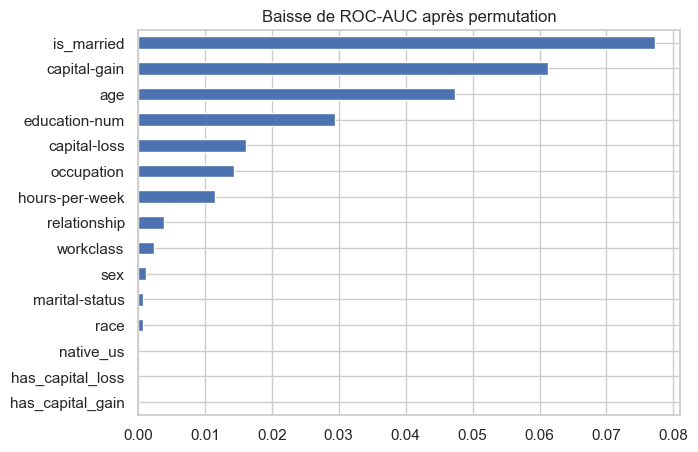

,importance
is_married,0.0772
capital-gain,0.0612
age,0.0473
education-num,0.0294
capital-loss,0.0161
occupation,0.0143
hours-per-week,0.0116
relationship,0.0038
workclass,0.0024
sex,0.0012


In [25]:
imp = permutation_importance(final, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp_s = pd.Series(imp.importances_mean, index=X_test.columns).sort_values()
imp_s.plot.barh(figsize=(7, 5), title="Baisse de ROC-AUC après permutation"); plt.show()
display(imp_s.sort_values(ascending=False).round(4).to_frame("importance"))

**Interprétation :** Variables les plus influentes : `is_married` (baisse de 0,077 de ROC-AUC si permutée), `capital-gain` (0,061), `age` (0,047), `education-num` (0,029), `capital-loss` (0,016), puis `occupation` et `hours-per-week`. `sex` et `race` pèsent peu (0,001), car `relationship` et `is_married` portent déjà l'essentiel de l'information. Les indicateurs `has_capital_*` ont une importance nulle (redondants avec le `log1p`) et pourraient être retirés. Interprétation prédictive, pas causale.

## 7.4 Lien segmentation × classification

In [26]:
seg_test = pd.Series(ref, index=df_clean.index).loc[X_test.index]
tmp = pd.DataFrame({"cluster": seg_test, "y": yt, "pred": pred})
lien = tmp.groupby("cluster").agg(Effectif=("y","size"), Reel_sup50K=("y","mean"), Predit_sup50K=("pred","mean"))
lien["Recall"] = tmp.groupby("cluster").apply(lambda g: recall_score(g["y"], g["pred"]))
lien[["Reel_sup50K","Predit_sup50K","Recall"]] *= 100
display(lien.round(1))

,Effectif,Reel_sup50K,Predit_sup50K,Recall
cluster,,,,
0,432,14.8,13.7,59.4
1,954,3.5,2.5,57.6
2,742,38.0,51.1,83.3
3,2894,10.9,12.8,61.8
4,2144,48.2,58.7,92.2
5,1945,28.7,41.9,80.9
6,647,7.9,2.2,25.5


**Interprétation :** Le rappel varie fortement selon le profil : excellent dans les clusters à fort taux de >50K (cluster 4 : 92,2 % ; cluster 2 : 83,3 %), faible dans les clusters 6 (25,5 %), 1 (57,6 %) et 0 (59,4 %), où les >50K sont rares et atypiques. Le modèle est plus fiable pour les profils « classiques » de haut revenu que pour les cas atypiques.

## 7.5 Bilan, limites et recommandations

- **Segmentation** : 7 profils interprétables, stables sous ré-échantillonnage (ARI 0,977 à k=7) mais de structure modérée (silhouette 0,342) ; initialisations multiples recommandées (ARI 0,892).
- **Classification** : le gradient boosting avec seuil 0,60 atteint F1 = 0,724, rappel = 0,815, précision = 0,652 et ROC-AUC = 0,933 sur le test, contre F1 0,672 et rappel 0,614 pour la régression logistique initiale.
- **Limites** : données de 1994 ; écart de performance hommes/femmes ; `fnlwgt` non utilisé ; seuil à adapter au coût métier.
- **Pistes** : seuils par sous-groupe, SMOTE, sélection de variables, cluster comme variable explicative.


# 8. Fichiers finaux : données nettoyées et préparées

In [27]:
prep_full = make_preprocessor().fit(X_train)                    # apprentissage sur le train uniquement
M = prep_full.transform(X)
names = [n.split("__", 1)[1] for n in prep_full.get_feature_names_out()]
prepared = pd.DataFrame(M, columns=names, index=X.index)
prepared["income"] = y.values
prepared["split"] = np.where(X.index.isin(X_train.index), "train", "test")
prepared["cluster"] = ref
prepared.to_csv("output/adult_prepared_model_ready.csv", index=False)

readable = df_clean.copy()
readable["hours-per-week"] = readable["hours-per-week"].clip(w.low_[1], w.high_[1])   # bornes apprises sur le train
readable["cluster"] = ref
readable.to_csv("output/adult_clean_readable.csv", index=False)
print("Fichier prêt pour modélisation :", prepared.shape, "| NaN :", int(prepared.isna().sum().sum()))
print("Fichier lisible nettoyé        :", readable.shape)

Fichier prêt pour modélisation : (48790, 53) | NaN : 0
Fichier lisible nettoyé        : (48790, 17)


**Interprétation :** Deux fichiers sont exportés dans `output/` : `adult_prepared_model_ready.csv` (48 790 lignes, variables transformées et encodées, cible, colonnes `split` train/test et `cluster`, sans NaN) et `adult_clean_readable.csv` (version nettoyée lisible, `hours-per-week` bornée avec les bornes du train). Le préprocesseur du fichier prêt à modéliser est appris sur le train uniquement.